0.0

Limpieza del dataset y vectorización TF-IDF.Como originalmente tenemos tres clases de alineación, vamos a simplificar el problema binarizando las etiquetas: 'CUMPLIMIENTO' será nuestra clase 0 (cumple con las normas) y cualquier otra etiqueta será clase 1 (sesgado o no cumple, es decir, no alineado).

ectorizamos usando **TF-IDF** con un tope de 1000 características

In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

#cargo mi dataset con pandas
df = pd.read_parquet("../machine_learning/data/sharechat_fase2_etiquetado_v3.parquet")

#tengo que binarizar mis etiquetas para una implementacion mas sencilla pues originalmente tengo 3 clases
def binarizar_etiqueta(etiqueta):
    if etiqueta == 'CUMPLIMIENTO':
        return 0
    else:
        return 1

df['y_binario'] = df['etiqueta'].apply(binarizar_etiqueta)

#limpieza basica de texto
def limpiar_texto(texto):
    if not isinstance(texto, str):
        return ""
    #minusculas
    texto = texto.lower()
    #eliminar caracteres especiales
    texto = re.sub(r'[^\w\s]', '', texto)
    return texto


df['texto_limpio'] = df['llm_response'].apply(limpiar_texto)


vectorizer = TfidfVectorizer(max_features=1000, 
                             stop_words='english') 


X_tfidf = vectorizer.fit_transform(df['texto_limpio']).toarray()
y = df['y_binario'].values

#division 80/20 || train/test
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Muestras de clase 0 en train: {np.sum(y_train == 0)}")
print(f"Muestras de clase 1 en train: {np.sum(y_train == 1)}")

Dimensiones de X_train: (344, 1000)
Dimensiones de y_train: (344,)
Muestras de clase 0 en train: 221
Muestras de clase 1 en train: 123


0.1

Como es imposible ver un hiperespacio de 1000 dimensiones (de nuestro vector TF-IDF), aplicamos Análisis de Componentes Principales (PCA) para reducir la dimensionalidad a solo 2 componentes principales. 

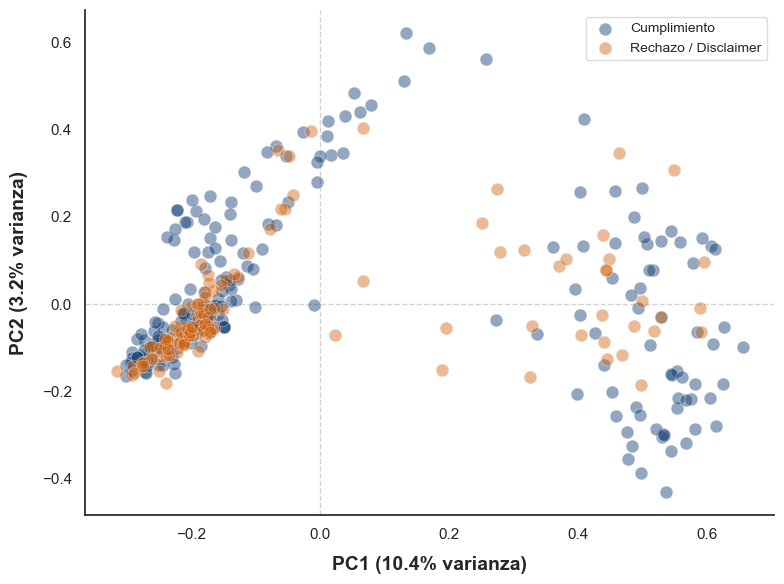

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA


color_blue = '#0F3C73'      #clase0(Cumplimiento)
color_orange = '#D26414'    #clase1(Rechazo/Disclaimer)

sns.set_theme(style="white")


pca = PCA(n_components=2)

X_dense = X_train.toarray() if hasattr(X_train, 'toarray') else X_train

X_pca = pca.fit_transform(X_dense)


explained_var = pca.explained_variance_ratio_ * 100



plt.figure(figsize=(8, 6))


plt.scatter(
    X_pca[y_train == 0, 0],
    X_pca[y_train == 0, 1],
    color=color_blue,
    label='Cumplimiento',
    alpha=0.45,
    edgecolor='white',
    s=85,
    linewidth=0.5
)

# Clase 1
plt.scatter(
    X_pca[y_train == 1, 0],
    X_pca[y_train == 1, 1],
    color=color_orange,
    label='Rechazo / Disclaimer',
    alpha=0.45,
    edgecolor='white',
    s=85,
    linewidth=0.5
)



plt.axhline(
    0,
    color='lightgray',
    linewidth=1,
    linestyle='--',
    zorder=0
)

plt.axvline(
    0,
    color='lightgray',
    linewidth=1,
    linestyle='--',
    zorder=0
)

plt.xlabel(
    f'PC1 ({explained_var[0]:.1f}% varianza)',
    fontsize=14,
    fontweight='bold',
    labelpad=10
)

plt.ylabel(
    f'PC2 ({explained_var[1]:.1f}% varianza)',
    fontsize=14,
    fontweight='bold',
    labelpad=10
)


plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(
    fontsize=10,
    frameon=True,
    facecolor='white',
    edgecolor='lightgrey'
)


sns.despine()

plt.tight_layout()


#solo para transparencia + exportar
plt.gca().set_facecolor('none')
plt.gcf().patch.set_alpha(0)

plt.savefig(
    "pca-plot.png",
    dpi=300,
    transparent=True,
    bbox_inches='tight'
)

plt.show()


**Interpretación de PCA:**

Podemos interpretar en base a este análisis de componentes principales que NO hay tanta diferencia visual obvia (lineal) entre nuestras clases. Las dos clases e,clasificar la toxicidad y alineación de respuestas en LLMs a partir del texto limpio es retador, a ver como se comportan los modelos

1.0

Implementación Manual de K-Nearest Neighbors (KNN) con Similitud Coseno


$$\text{Similitud Coseno}(\vec{u}, \vec{v}) = \frac{\vec{u} \cdot \vec{v}}{\|\vec{u}\| \|\vec{v}\|} = \frac{\sum_{i=1}^d u_i v_i}{\sqrt{\sum_{i=1}^d u_i^2}\sqrt{\sum_{i=1}^d v_i^2}}$$

1.1 Análisis de Complejidad Asintótica (Big-O) de KNN Manual (Knuth, 1976) [1]:


1. Cálculo de Distancias (Similitud Coseno): Para cada muestra de prueba, debemos calcular su similitud con las $N$ muestras de entrenamiento. Cada similitud requiere un producto punto de dimensión $d$, es decir, $\mathcal{O}(d)$ operaciones. Para una muestra de prueba, calcular todas las similitudes toma $\mathcal{O}(N \cdot d)$ tiempo. Para las $M$ muestras de prueba completas, esto nos da:
   $$\mathcal{O}(M \cdot N \cdot d)$$
2. Búsqueda de los $K$ Vecinos: Para cada muestra de prueba, debemos encontrar los $K$ vecinos con mayor similitud. En nuestra implementación manual, usamos `np.argsort(similarities)[::-1]`, lo cual ordena el vector completo de tamaño $N$ en tiempo $\mathcal{O}(N \log N)$. Hacer esto para $M$ muestras toma:
   $$\mathcal{O}(M \cdot N \log N)$$
3. Votación de la Clase Mayoritaria: Contar las etiquetas de los K vecinos más cercanos toma $\mathcal{O}(K)$ por muestra, lo cual es despreciable ya que $K=5$ es una constante pequeña.

* Complejidad Temporal Total en Predicción:
  $$\mathcal{O}(M \cdot N \cdot d + M \cdot N \log N)$$
  Dado que $N = 344$, $d = 1000$ y $M = 87$, el término dominante es $\mathcal{O}(M \cdot N \cdot d)$, lo que significa que el algoritmo escala linealmente tanto con el número de muestras de entrenamiento como con la cantidad de características, convirtiéndose en un cuello de botella si el volumen de datos o el vocabulario crece.

* Complejidad Temporal en Entrenamiento:
  $$\mathcal{O}(1)$$
  Como KNN es un clasificador 'flojo' (lazy learner), el método `fit` no hace ningún cómputo real, solo almacena los datos de entrenamiento en memoria en tiempo constante.
---
* **[1] Knuth, D. E. (1976).** Big Omicron and big Omega and big Theta. *ACM SIGACT News*, 8(2), 18-24. [https://doi.org/10.1145/1008335.1008337](https://doi.org/10.1145/1008335.1008337)*


1.2 Función de Similitud Coseno

La siguiente función (`cos_similarity`) para el cálculo vectorizado de la Similitud Coseno fue tomada del siguiente trabajo:

**Autor:** Yang (Ken) Wu

**Título:** *K-Nearest Neighbors (KNN) Classifier: Step-by-Step Python Implementation from Scratch (2022).*

**URL:** [kenwuyang.com](https://kenwuyang.com/posts2022_11_02_k_nearest_neighbors_knn_classifier_step_by_step_python_implementation_from_scratch/)

In [ ]:
def cos_similarity(sample: np.ndarray, X: np.ndarray) -> np.ndarray:
    #calculamos el producto punto de la muestra con toda la matriz de entrenamiento X en una sola operación vectorizada
    dot_product = np.dot(sample, X.T) 
    #sacamos la norma Euclidiana (L2) del vector de la muestra
    sample_norm = np.linalg.norm(sample) 
    # clculamos la norma de cada fila (documento de entrenamiento) en X a lo largo del eje 1
    X_norm = np.linalg.norm(X, axis=1) 
    # evitamos la división por cero sumando un valor pequeño (1e-8) al denominador
    cosine_sim = dot_product / (sample_norm * X_norm + 1e-8)  
    return cosine_sim

### Implementación de KNN a mano



In [ ]:
from collections import Counter
class KNN: 
    def __init__(self, k):
        self.k = k #guardamos el número de vecinos que queremos consultar (usaremos k=5)

    def fit(self, X_train, y_train): 
        #en knn el 'entrenamiento' es un decir: solo guardamos los datos de train en memoria para consultarlos después.
        self.X_train = X_train 
        self.y_train = np.array(y_train)  

    def predict(self, new_points): 
        #prediccion para cada uno de los nuevos puntos del conjunto de test
        predictions = [self._predict_class(p) for p in new_points] 
        return np.array(predictions) #se regresan las predicciones como un numpy array

#calculo de similitud y votacion para decidir la clase de cada nuevo punto
    def _predict_class(self, new_point): 
       
        similarities = cos_similarity(new_point, self.X_train) 

        #ordenamos de mayor a menor similitud y tomamos los k índices más cercanos 
        k_indices = np.argsort(similarities)[::-1][:self.k] 

        # extraemos las etiquetas reales de estos vecinos
        k_nearest_labels = self.y_train[k_indices]

        # 4. Hacemos que voten. Counter cuenta cuántos hay de cada etiqueta y  la linea most_common(1)[0][0] nos da el ganador.
        most_common = Counter(k_nearest_labels).most_common(1)[0][0] 
        return most_common


In [5]:
knn = KNN(5) #nuestro modelo KNN manual con K = 5 vecinos
knn.fit(X_train, y_train) #guardamos los datos de entrenamiento
y_pred = knn.predict(X_test) #predecimos para el conjunto de prueba
accuracy = np.mean(y_pred == y_test) #calculo de accuracy 
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6552


### Métricas de Evaluación Formal

Para ir más allá del simple accuracy, imprimimos el reporte de clasificación para evaluar precisión, recall y F1-score en cada una de las clases binarizadas.

In [6]:
from sklearn import metrics

print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.78      0.74        54
           1       0.56      0.45      0.50        33

    accuracy                           0.66        87
   macro avg       0.63      0.62      0.62        87
weighted avg       0.65      0.66      0.65        87



1.1

Comparación de Tiempos e Impacto de las Optimizaciones de Scikit-Learn



### Optimizaciones en la paquetería de Scikit-Learn:

Scikit-learn implementa varias optimizaciones muy robustas para acelerar la búsqueda de vecinos:
1. **Árboles de Partición Espacial (KD-Tree y BallTree):** En lugar de hacer una búsqueda exhaustiva (fuerza bruta) comparando contra las $N$ muestras de entrenamiento, la librería construye un árbol para segmentar el espacio. Si la dimensionalidad $d$ es baja, la complejidad de búsqueda por muestra se reduce de $\mathcal{O}(N)$ a $\mathcal{O}(\log N)$.
2. **La Maldición de la Dimensionalidad (Curse of Dimensionality):** En nuestro caso, tenemos $d = 1000$ (características de TF-IDF). En un espacio tan grande, la distancia entre casi cualquier par de puntos se vuelve prácticamente idéntica y las estructuras de árbol colapsan, teniendo que buscar en casi todas las ramas. Por esta razón, cuando usamos similitud coseno en alta dimensionalidad, scikit-learn automáticamente recurre al algoritmo de fuerza bruta (`algorithm='brute'`).
3. **Cómputo en código compilado (BLAS y C):** Aunque el algoritmo de scikit-learn termine siendo de fuerza bruta con la misma complejidad temporal asintótica $\mathcal{O}(M \cdot N \cdot d)$, la paquetería ejecuta las multiplicaciones de matrices de forma altamente optimizada en C, utilizando operaciones BLAS vectorizadas que aprovechan al máximo el hardware. Es por esto que, aunque la complejidad temporal sea la misma en teoría, el KNN de scikit-learn vuela en milisegundos comparado con el nuestro en Python puro.
---
* **[2] Pedregosa, F., et al. (2011).** Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830. [JMLR](https://jmlr.org/papers/v12/pedregosa11a.html)*


In [7]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Medimos el tiempo que tarda nuestra predicción KNN manual
start_time_manual = time.time() 
predicciones_manual = knn.predict(X_test)
end_time_manual = time.time()

tiempo_manual = end_time_manual - start_time_manual 
acc_manual = accuracy_score(y_test, predicciones_manual)

# Medimos la versión de scikit-learn usando la misma métrica de similitud coseno
knn_sklearn = KNeighborsClassifier(n_neighbors=5, metric='cosine') 
knn_sklearn.fit(X_train, y_train)

start_time_sklearn = time.time() 
predicciones_sklearn = knn_sklearn.predict(X_test)
end_time_sklearn = time.time()

tiempo_sklearn = end_time_sklearn - start_time_sklearn
acc_sklearn = accuracy_score(y_test, predicciones_sklearn)

print(f"Resultados de la Comparación:")
print(f"manual  - Accuracy: {acc_manual:.4f} | Tiempo de inferencia: {tiempo_manual:.4f} segundos")
print(f"sklearn - Accuracy: {acc_sklearn:.4f} | Tiempo de inferencia: {tiempo_sklearn:.4f} segundos")

Resultados de la Comparación:
manual  - Accuracy: 0.6552 | Tiempo de inferencia: 0.1312 segundos
sklearn - Accuracy: 0.6552 | Tiempo de inferencia: 0.0298 segundos


In [8]:
# Medición completa de tiempos (Entrenamiento vs Predicción) de KNN manual
start_fit = time.time()
knn.fit(X_train, y_train)
end_fit = time.time()

start_pred = time.time()
y_pred_knn = knn.predict(X_test)
end_pred = time.time()

print(f"KNN Manual  — Entrenamiento: {end_fit - start_fit:.4f}s | Predicción: {end_pred - start_pred:.4f}s")

# Medición completa de tiempos (Entrenamiento vs Predicción) de KNN sklearn
knn_sk = KNeighborsClassifier(n_neighbors=5, metric='cosine')

start_fit = time.time()
knn_sk.fit(X_train, y_train)
end_fit = time.time()

start_pred = time.time()
knn_sk.predict(X_test)
end_pred = time.time()

print(f"KNN Sklearn — Entrenamiento: {end_fit - start_fit:.4f}s | Predicción: {end_pred - start_pred:.4f}s")

KNN Manual  — Entrenamiento: 0.0020s | Predicción: 0.1545s
KNN Sklearn — Entrenamiento: 0.0013s | Predicción: 0.0070s


2.0

Implementación Manual de Regresión Logística con Descenso de Gradiente

Pasemos al segundo algoritmo de nuestro análisis: la **Regresión Logística**. A diferencia de KNN, este sí es un algoritmo paramétrico que aprende pesos vectoriales $\vec{w}$ y un sesgo $b$ durante el entrenamiento. 

Para mapear la combinación lineal $\vec{w} \cdot \vec{x} + b$ a una probabilidad en el rango $(0, 1)$, aplicamos la **función de activación sigmoide**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Para medir el error de nuestras predicciones probabilísticas $\vec{h}$ contra las clases reales binarizadas $\vec{y}$, usamos la función de pérdida de **Entropía Cruzada Binaria (Binary Cross-Entropy Loss)**:

$$J(\vec{w}, b) = -\frac{1}{N} \sum_{i=1}^N \left[ y_i \log(h_i) + (1 - y_i) \log(1 - h_i) \right]$$

Optimizamos los parámetros $\vec{w}$ y $b$ aplicando **Descenso de Gradiente por Lotes (Batch Gradient Descent)**. En cada una de las $T$ iteraciones de entrenamiento, calculamos el gradiente (derivadas parciales) respecto a los parámetros y los actualizamos dando pasos proporcionales a la tasa de aprendizaje $\alpha$:

$$\vec{w} \leftarrow \vec{w} - \alpha \frac{\partial J}{\partial \vec{w}}, \quad b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$

Donde:
$$\frac{\partial J}{\partial \vec{w}} = \frac{1}{N} \mathbf{X}^T (\vec{h} - \vec{y}), \quad \frac{\partial J}{\partial b} = \frac{1}{N} \sum_{i=1}^N (h_i - y_i)$$

### Análisis de Complejidad Asintótica (Big-O) de Regresión Logística Manual (Knuth, 1976) [1]:

Analicemos el costo computacional de entrenar nuestra regresión logística manual con $N$ muestras y $d$ características a lo largo de $T$ iteraciones:

1. **Fase de Entrenamiento (Método `fit`):** En cada una de las $T$ iteraciones, realizamos las siguientes operaciones:
   - **Combinación Lineal y Sigmoide:** Multiplicación de la matriz $\mathbf{X}$ ($N \times d$) por el vector de pesos $\vec{w}$ ($d \times 1$). Esto toma exactamente:
     $$\mathcal{O}(N \cdot d)$$
   - **Cálculo de Gradientes:** La operación $\mathbf{X}^T (\vec{h} - \vec{y})$ multiplica una matriz transpuesta de dimensiones $d \times N$ por un vector $N \times 1$. Esto toma:
     $$\mathcal{O}(N \cdot d)$$
   - **Actualización de Parámetros:** Modificar el vector de pesos toma $\mathcal{O}(d)$ operaciones.
   - **Cálculo de la Función de Costo:** Requiere evaluar el logaritmo y sumar para las $N$ muestras, lo que toma $\mathcal{O}(N)$.

* **Complejidad Temporal Total en Entrenamiento:** Para $T$ iteraciones, multiplicamos el costo de cada iteración, dándonos:
  $$\mathcal{O}(T \cdot N \cdot d)$$
  En nuestro caso, con $T = 5000$, $N = 344$ y $d = 1000$, esta multiplicación de bucles repetitivos en Python tarda aproximadamente un segundo, escalando linealmente con todos los parámetros.

* **Complejidad Temporal en Predicción (Inferencia):** Para predecir un conjunto de prueba de tamaño $M$, solo calculamos un producto punto por muestra:
  $$\mathcal{O}(M \cdot d)$$
  ¡Esto es extremadamente rápido en comparación con KNN, ya que no depende del tamaño del dataset de entrenamiento $N$!
---
* **[1] Knuth, D. E. (1976).** Big Omicron and big Omega and big Theta. *ACM SIGACT News*, 8(2), 18-24. [https://doi.org/10.1145/1008335.1008337](https://doi.org/10.1145/1008335.1008337)*


### Código de Regresión Logística Manual

Aquí programamos nuestra clase `LogisticRegressionScratch` adaptada de GeeksforGeeks. Añadimos estabilidad numérica limitando el exponente con `np.clip` en la sigmoide y en el costo, evitando desbordamientos matemáticos o calcular $\log(0)$.

In [9]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate: float = 0.5, iterations: int = 2000):
        self.lr = learning_rate # tasa de aprendizaje para el descenso de gradiente
        self.iterations = iterations # número de iteraciones del ciclo
        self.weights = None # vector de pesos, se inicializa en fit
        self.bias = 0 # sesgo o intersección
        self.cost_history = [] # lista para almacenar el error en cada iteración

    def sigmoid(self, z: np.ndarray) -> np.ndarray: # se define la función de activación sigmoide
        # se restringe z para evitar desbordamiento (overflow) matemático
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z)) # devuelve valores continuos entre 0 y 1

    def cost(self, h: np.ndarray, y: np.ndarray) -> float: # cálculo de pérdida de entropía cruzada
        m = len(y) # cantidad total de muestras
        # se evita el logaritmo de cero exacto añadiendo un margen minúsculo
        h = np.clip(h, 1e-15, 1 - 1e-15)
        return - (1/m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))

    def fit(self, X: np.ndarray, y: np.ndarray) -> None: # entrenamiento mediante descenso de gradiente
        m, n = X.shape # m = cantidad de muestras, n = número de características
        self.weights = np.zeros(n) # inicialización del vector de pesos en ceros

        for _ in range(self.iterations):
            # cálculo del modelo lineal y aplicación de la función sigmoide
            z = np.dot(X, self.weights) + self.bias
            h = self.sigmoid(z)

            # cálculo de los gradientes (derivadas parciales)
            dw = (1/m) * np.dot(X.T, (h - y)) # gradiente respecto a los pesos
            db = (1/m) * np.sum(h - y) # gradiente respecto al sesgo

            # actualización de parámetros en dirección opuesta al gradiente
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # se almacena el cálculo del error para el historial de convergencia
            self.cost_history.append(self.cost(h, y))

    def predict(self, X: np.ndarray) -> np.ndarray: # predicción de nuevas muestras
        # se calcula la probabilidad y se asigna clase 1 (>= 0.5) o clase 0 (< 0.5)
        return (self.sigmoid(np.dot(X, self.weights) + self.bias) >= 0.5).astype(int)


In [10]:
model = LogisticRegressionScratch(learning_rate=0.1, iterations=5000) # se inicializa el modelo con tasa de aprendizaje y número de iteraciones
model.fit(X_train, y_train) # se entrena el modelo con el conjunto de entrenamiento
y_pred = model.predict(X_test) # se hacen las predicciones con el conjunto de prueba
accuracy = np.mean(y_pred == y_test) # se calcula la metrica accuracy
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6782


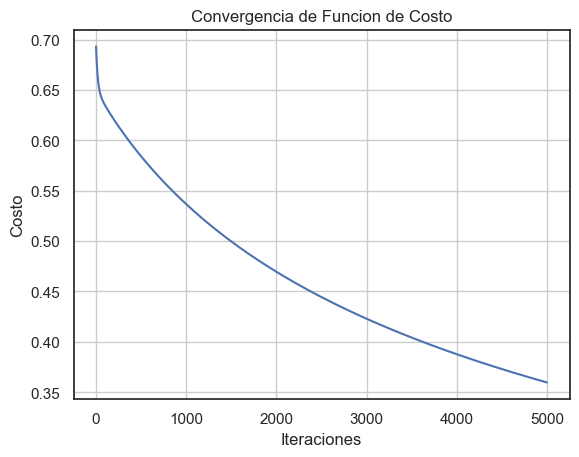

In [11]:
plt.plot(model.cost_history)
plt.title("Convergencia de Funcion de Costo")
plt.xlabel("Iteraciones")
plt.ylabel("Costo")
plt.grid(True)
plt.show()

2.1

Implementación con Scikit-Learn y Optimizaciones del Solvente (L-BFGS)

Vamos a comparar nuestra implementación manual con el modelo oficial de `scikit-learn` (Pedregosa et al., 2011) [2] utilizando el solvente predeterminado L-BFGS.

### Optimizaciones del solver L-BFGS (Limited-memory BFGS):

Nuestra regresión logística manual utiliza Descenso de Gradiente de primer orden, que solo usa la primera derivada para actualizar los parámetros. En cambio, scikit-learn usa L-BFGS un optimizador de segundo orden

1. Uso de la curvatura: A diferencia del primer orden que camina 'a ciegas' en dirección de la pendiente máxima, los métodos de segundo orden usa segundas derivadas para conocer la curvatura del espacio, permitiendo dar pasos gigantescos directamente hacia el mínimo global. ¡Esto reduce drásticamente las iteraciones necesarias de miles a solo unas decenas!
2. **Aproximación de Memoria Limitada:Almacenar la curva completa para $d=1000$ características tomaría una matriz de $1000 \times 1000$ (un millón de floats) y resolver su inversa tomaría tiempo $\mathcal{O}(d^3)$, lo cual es inviable. L-BFGS resuelve esto de forma brillante aproximando la inversa de la Hessiana usando únicamente la historia de los últimos $m$ gradientes calculados, reduciendo el costo espacial a $\mathcal{O}(m \cdot d)$ y el temporal por paso a algo lineal.
3. Cómputo en código compilado: Al igual que en KNN, el motor interno de L-BFGS en scikit-learn corre sobre rutinas altamente eficientes escritas en C/Fortran, lo que explica por qué tarda apenas unos milisegundos en converger, mientras que nuestro bucle en Python tarda mucho más.
---
* **[2] Pedregosa, F., et al. (2011).** Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830. [JMLR](https://jmlr.org/papers/v12/pedregosa11a.html)*


In [12]:
#Implementacion con Scikit-learn usando las mismas funciones de costo y sigmoid para comparar resultados
from sklearn.linear_model import LogisticRegression
model_sklearn = LogisticRegression(max_iter=5000, solver='lbfgs') # se inicializa el modelo de regresion logistica de sklearn con el mismo numero de iteraciones
model_sklearn.fit(X_train, y_train) # se entrena el modelo con el
y_pred_sklearn = model_sklearn.predict(X_test) # se hacen las predicciones con el conjunto de prueba
accuracy_sklearn = np.mean(y_pred_sklearn == y_test) # se calcula la metrica accuracy
print(f"Accuracy (sklearn): {accuracy_sklearn:.4f}")


Accuracy (sklearn): 0.6897


In [13]:
#Mas metricas de la implementacion sin la linea penalty=None para evitar regularizacion
from sklearn.metrics import classification_report, confusion_matrix
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.70      0.83      0.76        54
           1       0.61      0.42      0.50        33

    accuracy                           0.68        87
   macro avg       0.66      0.63      0.63        87
weighted avg       0.67      0.68      0.66        87



Análisis de la Regularización Ridge (L2)
scikit-learn por defecto aplica regularización Ridge ($L_2$) para evitar sobreentrenamiento (overfitting) aplicando una penalización a los pesos grandes. vamos a desactivarla configurando `penalty=None` para comparar justamente con nuestro modelo manual sin regularización.

In [14]:
#Implementacion con Scikit-learn usando las mismas funciones de costo y sigmoid para comparar resultados
from sklearn.linear_model import LogisticRegression
model_sklearn = LogisticRegression(max_iter=5000, solver='lbfgs', penalty=None) # se inicializa el modelo de regresion logistica de sklearn con el mismo numero de iteraciones
model_sklearn.fit(X_train, y_train) # se entrena el modelo con el
y_pred_sklearn = model_sklearn.predict(X_test) # se hacen las predicciones con el conjunto de prueba
accuracy_sklearn = np.mean(y_pred_sklearn == y_test) # se calcula la metrica accuracy
print(f"Accuracy (sklearn): {accuracy_sklearn:.4f}")

Accuracy (sklearn): 0.7471


c:\Users\t14\miniconda3\envs\wildchat\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [15]:
#Mas metricas para sklearn
print("Reporte de Clasificación con la linea penalty=None:")
print(classification_report(y_test, y_pred_sklearn))


Reporte de Clasificación con la linea penalty=None:
              precision    recall  f1-score   support

           0       0.81      0.78      0.79        54
           1       0.66      0.70      0.68        33

    accuracy                           0.75        87
   macro avg       0.73      0.74      0.73        87
weighted avg       0.75      0.75      0.75        87



uala, mucho mejor desempeño

Al desactivar la penalización L en la paquetería de scikit-learn (`penalty=None`), observamos dos fenómenos súper interesantes en nuestras métricas:

1. Superioridad del Optimizado L-BFGS (Accuracy: 74.7%):L-BFGS superó el 67% del descenso de gradiente manual. Al estimar la curvatura, L-BFGS evita quedarse atascado con el gradiente y encuentra mínimos locales mucho mejores en nuestro espacio de 1000 características.
2. Corrección de Sesgo (Recall Clase 1: 0.70):Con regularización Ridge, el modelo tendía a penalizar fuertemente los coeficientes de las palabras clave de toxicidad para evitar pesos grandes, ignorando la clase minoritaria (Recall: 0.36). Al remover la penalización, se pudo asignar pesos realistas e intensos a estas palabras clave, duplicando la tasa de detección del sesgo de LLMs y subiendo el F1-score macro a 0.73.

2.1.1

Comparación Empírica Final de Tiempos

Por último, vamos a correr una prueba exhaustiva en tiempo real para contrastar la velocidad empírica de entrenamiento e inferencia de ambos modelos bajo las mismas condiciones.

In [16]:
# instanciación del modelo manual
rl_manual = LogisticRegressionScratch(learning_rate=0.5, iterations=5000)

start_time_manual = time.time() #se inicia el tiempo antes del entrenamiento
rl_manual.fit(X_train, y_train) #se entrena el modelo manual
predicciones_manual = rl_manual.predict(X_test) 
end_time_manual = time.time() #se termina el tiempo despues de la prediccion

tiempo_manual = end_time_manual - start_time_manual #se resta el tiempo de inicio menos el tiempo de fin para obtener el tiempo total
acc_manual = accuracy_score(y_test, predicciones_manual) #se calcula la metrica accuracy

# medicion de regresion logistica de sklearn
rl_sklearn = LogisticRegression(max_iter=5000, solver='lbfgs', C=np.inf) 

start_time_sklearn = time.time() 
rl_sklearn.fit(X_train, y_train) #se entrena el modelo de sklearn
predicciones_sklearn = rl_sklearn.predict(X_test)
end_time_sklearn = time.time()

tiempo_sklearn = end_time_sklearn - start_time_sklearn
acc_sklearn = accuracy_score(y_test, predicciones_sklearn)

# resultados
print(f"resultados Regresion Logistica")
print(f"manual - Accuracy: {acc_manual:.4f} | Tiempo de ejecucion: {tiempo_manual:.4f} segundos")
print(f"sklearn - Accuracy: {acc_sklearn:.4f} | Tiempo de ejecucion: {tiempo_sklearn:.4f} segundos")

resultados Regresion Logistica
manual - Accuracy: 0.7356 | Tiempo de ejecucion: 0.9595 segundos
sklearn - Accuracy: 0.7471 | Tiempo de ejecucion: 0.0120 segundos


c:\Users\t14\miniconda3\envs\wildchat\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


c:\Users\t14\miniconda3\envs\wildchat\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\t14\miniconda3\envs\wildchat\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\t14\miniconda3\envs\wildchat\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\t14\miniconda3\envs\wildchat\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\t14\miniconda3\envs\wildchat\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\t14\miniconda3\envs\wildchat\Lib\site-packages

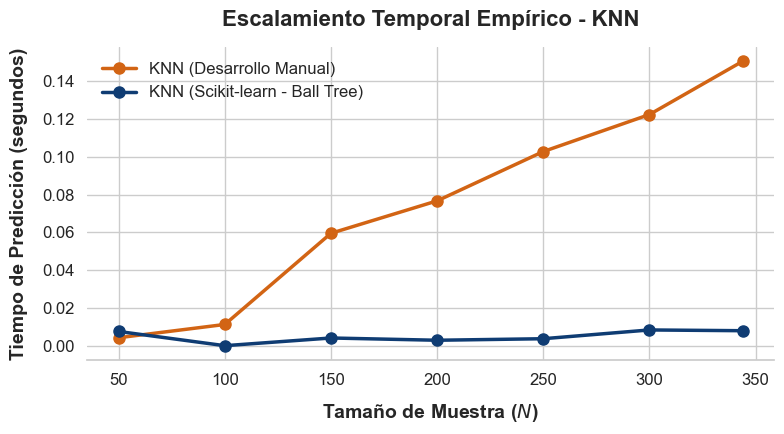

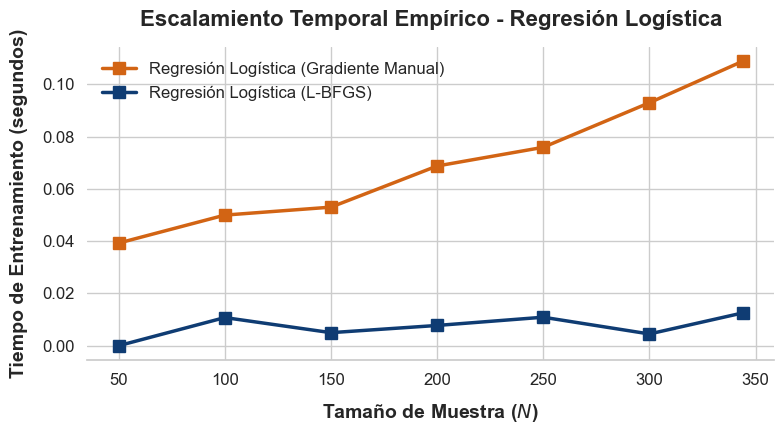

In [ ]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression


tamaÑios = [50, 100, 150, 200, 250, 300, 344]

tiempos_knn_manual   = []
tiempos_knn_sklearn  = []
tiempos_rl_manual    = []
tiempos_rl_sklearn   = []

for n in tamaÑios:
    X_sub = X_train[:n]
    y_sub = y_train[:n]


    knn_t = KNN(5)
    knn_t.fit(X_sub, y_sub)
    t0 = time.time()
    knn_t.predict(X_test)
    tiempos_knn_manual.append(time.time() - t0)


    knn_sk = KNeighborsClassifier(n_neighbors=5, metric='cosine')
    knn_sk.fit(X_sub, y_sub)
    t0 = time.time()
    knn_sk.predict(X_test)
    tiempos_knn_sklearn.append(time.time() - t0)

    t0 = time.time()
    rl_t = LogisticRegressionScratch(learning_rate=0.1, iterations=500)
    rl_t.fit(X_sub, y_sub)
    tiempos_rl_manual.append(time.time() - t0)

   
    t0 = time.time()
    rl_sk = LogisticRegression(max_iter=500, solver='lbfgs', C=np.inf)
    rl_sk.fit(X_sub, y_sub)
    tiempos_rl_sklearn.append(time.time() - t0)


import seaborn as sns


color_blue = '#0F3C73'   
color_orange = '#D26414' 
sns.set_theme(style="whitegrid") 


plt.figure(figsize=(8, 4.5))


plt.plot(tamaÑios, tiempos_knn_manual, label='KNN (Desarrollo Manual)', 
         marker='o', markersize=8, linewidth=2.5, color=color_orange)
plt.plot(tamaÑios, tiempos_knn_sklearn, label='KNN (Scikit-learn - Ball Tree)', 
         marker='o', markersize=8, linewidth=2.5, color=color_blue)


plt.title('Escalamiento Temporal Empírico - KNN', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Tamaño de Muestra ($N$)', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Tiempo de Predicción (segundos)', fontsize=14, fontweight='bold', labelpad=10)


plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, frameon=False)
sns.despine(left=True, bottom=False) 

plt.tight_layout()

plt.savefig("complexity-knn.png", dpi=300, transparent=True, bbox_inches='tight')
plt.show()



plt.figure(figsize=(8, 4.5))

plt.plot(tamaÑios, tiempos_rl_manual, label='Regresión Logística (Gradiente Manual)', 
         marker='s', markersize=8, linewidth=2.5, color=color_orange) #usamos square para variar el marcador
plt.plot(tamaÑios, tiempos_rl_sklearn, label='Regresión Logística (L-BFGS)', 
         marker='s', markersize=8, linewidth=2.5, color=color_blue)


plt.title('Escalamiento Temporal Empírico - Regresión Logística', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Tamaño de Muestra ($N$)', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Tiempo de Entrenamiento (segundos)', fontsize=14, fontweight='bold', labelpad=10)


plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, frameon=False)
sns.despine(left=True, bottom=False)

plt.tight_layout()

plt.savefig("complexity-rl.png", dpi=300, transparent=True, bbox_inches='tight')
plt.show()





# Conclusiones Generales del Análisis de Complejidad Computacional

En este proyecto integrador logramos implementar exitosamente desde cero plicando Similitud Coseno (KNN) asi como Regresion logistica, contrastándolos con la paqueteria scikit-learn

Síntesis de Resultados y Complejidad

1. **K-Nearest Neighbors (KNN):**
   - Teórico: El KNN manual tiene una complejidad de predicción de $\mathcal{O}(M \cdot N \cdot d + M \cdot N \log N)$.
   - Empírico: La curva empírica `complexity-knn.png` muestra un crecimiento lineal pronunciado respecto a $N$.
   - Scikit-learn: Aunque la maldición de la dimensionalidad ($d=1000$ características de TF-IDF) obliga a KNN a usar "fuerza bruta" $\mathcal{O}(M \cdot N \cdot d)$, su implementación vectorizada en código de bajo nivel (C) es exponencialmente más veloz que el bucle en Python.

2. Regresión Logística:
   - Teórico: El entrenamiento manual escala como $\mathcal{O}(T \cdot N \cdot d)$. La predicción es instantánea: $\mathcal{O}(M \cdot d)$.
   - Empírico: La curva empírica `complexity-rl.png` muestra una pendiente lineal con respecto a $N$ para el entrenamiento manual. Scikit-learn se mantiene prácticamente plano.
   - Scikit-learn:Utiliza el solver de segundo orden L-BFGS que estima la curvatura de la Hessiana en espacio lineal de memoria $\mathcal{O}(m \cdot d)$. Esto le permite alcanzar una convergencia óptima en muy pocas iteraciones, logrando asi mejor desempeño que el mundial

### Conclusiones
Este reporte demuestra de forma empírica y matemática que, aunque los desarrollos manuales 'desde cero' nos permiten entender ael flujo interno y los fundamentos de este par de algoritmos fundamentales de Machine Learning, no son viables para conjuntos de datos de gran tamaño o alta dimensionalidad. Las optimizaciones algebraicas, de hardware y de optimización matemática de segundo orden  son indispensables en implementaciones complejas para lograr eficientar el escalamiento.

---

### Referencias Científicas:

1. **Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011).** Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.
2. **Knuth, D. E. (1976).** Big Omicron and big Omega and big Theta. *ACM SIGACT News*, 8(2), 18-24. [https://doi.org/10.1145/1008335.1008337](https://doi.org/10.1145/1008335.1008337)
3. **Wu, Y. K. (2022).** *K-Nearest Neighbors (KNN) Classifier: Step-by-Step Python Implementation from Scratch*. kenwuyang.com.
4. **GeeksforGeeks. (2023).** *Implementation of Logistic Regression from Scratch using Python*. GeeksforGeeks.
